**Master's Degree in Applied Artificial Intelligence**

**Course: Data science and analytics**

Tecnológico de Monterrey

Ricardo Martin Galvan Paez


---



This notebook will work with `personal_loan.csv` file, based on a dataset regarding bank custumers and their financial behavior available on Kaggle.

The data were collected to analyze the likelihood of customers accepting a personal loan and include demographic and financial information, as well as details on associated banking products. The indicators included are:
* `ID`: Unique customer identifier
* `Age`: Customer's age (in years)
* `Experience`: Work experience in years
* `Income`: Customer's annual income (in thousands of dollars; e.g., 60 = 60,000 USD/year)
* `ZIP Code`: Customer's ZIP code
* `Family`: Number of family members
* `CCAvg`: Average monthly credit card spending (in thousands of dollars)
* `Education`: Education level (1 = undergraduate, 2 = graduate, 3 = postgraduate)
* `Mortgage`: Value of the customer's mortgage (in thousands of dollars)
* `Securities Account`: Indicator of whether the customer has a securities account (1 = yes, 0 = no)
* `CD Account`: Indicator of whether the customer has a certificate of deposit account (1 = yes, 0 = no)
* `Online`: Indicator of whether the customer uses online banking services (1 = yes, 0 = no)
* `CreditCard`: Indicator of whether the customer holds a credit card (1 = yes, 0 = no)
* `Personal Loan`: Whether the customer accepted (1) or did not accept (0) a personal loan. This is the output or *target* variable—the one to be predicted later when building the model.



In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

1. Download the file `personal_loan.csv` and save all its records into a DataFrame (`loan_df`).
* Set the `ID` column as the DataFrame's index.
* Use the DataFrame's `info()` method to get a summary of the data types. How many columns are numeric and how many are text?


---



In [2]:
## We obtain the dataset from our drive
import os
from google.colab import drive

drive.mount('/content/drive')
DIR = "/content/drive/MyDrive/Colab Notebooks/DSML_Projects/EDA"
os.chdir(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We have a total of 13 columns and 5037 observations. These are the types of the columns:
* `Object or text`: 5
* `int and float`: 8

In [3]:
loan_df = pd.read_csv('personal_loan.csv', index_col='ID')
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   object 
 9   Securities Account  5037 non-null   object 
 10  CD Account          5037 non-null   object 
 11  Online              5037 non-null   object 
 12  CreditCard          5037 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 550.9+ KB


# Cleaning

2. Obtain descriptive statistics for the numerical variables and carefully examine the values ​​obtained for each column.
* Filter the dataframe to view records where age exceeds 100 years and remove them if they are implausible.
* Analyze the remaining variables and remove records containing invalid or inconsistent values. For each action taken, justify your decision by explaining why you consider the value to be incorrect.
* How many records were removed (considering all actions in this exercise), and what percentage do they represent of the total initial dataframe?


---



Based on these descriptive data, the presence of irregular values ​​is observed, such as ages exceeding 100 years, as well as negative values ​​in the experience and family fields.

In [4]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5037.0,45.411356,11.646805,23.0,35.0,45.0,55.0,144.0
Experience,5037.0,20.122494,11.461278,-3.0,10.0,20.0,30.0,43.0
Income,5037.0,73.898352,46.130504,8.0,39.0,64.0,98.0,224.0
ZIP Code,5037.0,93152.865595,2119.637960,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5037.0,2.394679,1.151145,-3.0,1.0,2.0,3.0,4.0
CCAvg,5037.0,1.942404,1.755954,0.0,0.7,1.5,2.6,10.0
Education,5037.0,1.880941,0.843337,1.0,1.0,2.0,3.0,7.3
Mortgage,5037.0,56.500695,101.657580,0.0,0.0,0.0,101.0,635.0


We have only three observations where the age exceeds 100 years, representing 0.06% of the total observations, so we can remove them without issue.

In [5]:
loan_df[loan_df['Age'] > 100]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
10,123,39,105,94710,4,2.4,3.0,0,0,0,0,No,0
250,144,6,29,94305,3,1.0,2.0,117,0,No,0,No,No
4800,130,7,73,94028,1,2.5,1.0,135,0,No,0,0,0


In [6]:
pctOver100Years = len(loan_df[loan_df['Age'] > 100]) / len(loan_df) * 100
print(f"Percentage of records with age greater than 100: {pctOver100Years:.2f}%")

Percentage of records with age greater than 100: 0.06%


In [7]:
loan_df.drop(loan_df[loan_df['Age'] > 100].index, inplace=True)
loan_df.reset_index(drop=True, inplace=True)

In [8]:
pctexp = len(loan_df[loan_df['Experience'] < 0]) / len(loan_df) * 100
print(f"Percentage of records with negative experience: {pctexp:.2f}%")

loan_df.drop(loan_df[loan_df['Experience'] < 0].index, inplace=True)
loan_df.reset_index(drop=True, inplace=True)

Percentage of records with negative experience: 1.05%


In [9]:
pctfam = len(loan_df[loan_df['Family'] < 0]) / len(loan_df) * 100
print(f"Percentage of records with negative family: {pctfam:.2f}%")

loan_df.drop(loan_df[loan_df['Family'] < 0].index, inplace=True)
loan_df.reset_index(drop=True, inplace=True)

Percentage of records with negative family: 0.04%


For the other two fields, Experience and Family, we remove negative values, as they cannot take on such values.

These are the percentages that were eliminated from the three fields:
* `Age`: 0.06%
* `Experience`: 1.05%
* `Family`: 0.04%

========================
* `total`: 1.15%

We did this because it is very important to clean the data before analyzing it; if the entire analysis process is carried out with poor-quality data, the result will also be poor.

In [10]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4979.0,45.579434,11.308712,24.0,36.0,46.0,55.0,67.0
Experience,4979.0,20.352882,11.301033,0.0,11.0,20.0,30.0,43.0
Income,4979.0,73.940149,46.205921,8.0,39.0,64.0,98.0,224.0
ZIP Code,4979.0,93150.585861,2125.175857,9307.0,91910.5,93437.0,94608.0,96651.0
Family,4979.0,2.391243,1.148641,1.0,1.0,2.0,3.0,4.0
CCAvg,4979.0,1.940382,1.756574,0.0,0.7,1.5,2.6,10.0
Education,4979.0,1.878349,0.843214,1.0,1.0,2.0,3.0,7.3
Mortgage,4979.0,56.652942,101.810288,0.0,0.0,0.0,101.0,635.0


3. Obtain descriptive statistics for the text variables and print the frequencies of their categories.
* Some columns store binary values ​​using different formats. Standardize these values ​​consistently, ensuring they match the variable descriptions provided at the beginning of this notebook.


---



We know that the object field must have only two unique values, since they are binary: 1 for "yes" and 0 for "no".

In [11]:
loan_df.describe(include='object').T

,count,unique,top,freq
Personal Loan,4979,4,0,3476
Securities Account,4979,4,No,2693
CD Account,4979,4,No,2462
Online,4979,4,Yes,1700
CreditCard,4979,4,0,2628


In [12]:
cat_cols = loan_df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"Column: {col}")
    print(loan_df[col].value_counts())
    print('='*30)

Column: Personal Loan
Personal Loan
0      3476
No     1018
Yes     368
1       117
Name: count, dtype: int64
Column: Securities Account
Securities Account
No     2693
0      1766
Yes     391
1       129
Name: count, dtype: int64
Column: CD Account
CD Account
No     2462
0      2213
1       163
Yes     141
Name: count, dtype: int64
Column: Online
Online
Yes    1700
No     1628
1      1277
0       374
Name: count, dtype: int64
Column: CreditCard
CreditCard
0      2628
Yes     909
No      885
1       557
Name: count, dtype: int64


In [13]:
for col in cat_cols:
    loan_df[col] = loan_df[col].replace({'1': 'Yes', '0': 'No'})
loan_df.describe(include='object').T

,count,unique,top,freq
Personal Loan,4979,2,No,4494
Securities Account,4979,2,No,4459
CD Account,4979,2,No,4675
Online,4979,2,Yes,2977
CreditCard,4979,2,No,3513


4. Check for duplicate records and, if found, remove them from the DataFrame.
* Make sure to reset the index to maintain a continuous sequence following all the record deletions performed up to this point.


---



We can see that there are a total of 36 duplicates, so we remove them from the dataframe.

In [14]:
total_dup = loan_df.duplicated().sum()

print(f"Total number of duplicate records: {total_dup}")

loan_df.drop_duplicates(inplace=True)
loan_df.reset_index(drop=True, inplace=True)

total_dup = loan_df.duplicated().sum()
print(f"Total number of duplicate records after removal: {total_dup}")

Total number of duplicate records: 36
Total number of duplicate records after removal: 0


5. Although the data types inferred by pandas have been considered so far, it is advisable to review the statistical nature of each variable (continuous, discrete, categorical, binary, etc.) before performing EDA in order to apply the appropriate analysis.

* Perform the following conversions:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` with order 1, 2, 3
  - Binary: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Create two lists named `num_cols` and `cat_cols` containing the names of the numerical (int64, float64) and categorical (object, category) variables in the dataset, respectively.


---



Next, we correct the dataset's data types, as pandas inferred some them incorrectly. And we create two lists, one containing numerical values ​​and the other categorical values to facilitate more efficient analysis later on.

In [15]:
loan_df['ZIP Code'] = loan_df['ZIP Code'].astype('object')
loan_df['Education'] = loan_df['Education'].astype('category').cat.set_categories([1, 2, 3], ordered=True)
loan_df[cat_cols] = loan_df[cat_cols].astype('category')
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 4943 non-null   int64   
 1   Experience          4943 non-null   int64   
 2   Income              4943 non-null   int64   
 3   ZIP Code            4943 non-null   object  
 4   Family              4943 non-null   int64   
 5   CCAvg               4943 non-null   float64 
 6   Education           4942 non-null   category
 7   Mortgage            4943 non-null   int64   
 8   Personal Loan       4943 non-null   category
 9   Securities Account  4943 non-null   category
 10  CD Account          4943 non-null   category
 11  Online              4943 non-null   category
 12  CreditCard          4943 non-null   category
dtypes: category(6), float64(1), int64(5), object(1)
memory usage: 300.1+ KB


In [16]:
num_cols = loan_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = loan_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']
Categorical columns: ['ZIP Code', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


6. For the analysis of the numerical variables, obtain the descriptive statistics again, including the skewness and kurtosis values.
* Classify the variables `Age`, `Income`, and `Mortgage` based on the observed skewness and kurtosis values.


---



* `Age`: It exhibits an approximately symmetrical shape, as the skewness falls between -0.5 and +0.5, and the kurtosis indicates a platykurtic distribution, meaning that the age observations within the dataset are highly diverse.
* `Income`: Exhibits a slightly asymmetrical shape, with a positive skewness of 0.84 and a kurtosis of -0.045 indicating that the distribution is approximately mesokurtic, meaning the data follow a "normal" distribution.
* `Mortgage`: The skewness indicates that the distribution is asymmetric, with a value of 2.1 and negative skew; meanwhile, the kurtosis of 4.76 reveals a leptokurtic distribution, meaning the data are concentrated within a narrow range of values.

In [17]:
num_stats = loan_df[num_cols].describe().T
num_stats['skewness'] = loan_df[num_cols].skew()
num_stats['kurtosis'] = loan_df[num_cols].kurtosis()
num_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Age,4943.0,45.557152,11.317371,24.0,36.0,46.0,55.0,67.0,-0.023114,-1.161292
Experience,4943.0,20.332187,11.309957,0.0,11.0,20.0,30.0,43.0,-0.015524,-1.134567
Income,4943.0,73.809630,46.105644,8.0,39.0,64.0,98.0,224.0,0.842448,-0.045446
Family,4943.0,2.391867,1.148253,1.0,1.0,2.0,3.0,4.0,0.159299,-1.403894
CCAvg,4943.0,1.935517,1.748162,0.0,0.7,1.5,2.6,10.0,1.595181,2.637713
Mortgage,4943.0,56.640704,101.861109,0.0,0.0,0.0,101.0,635.0,2.104501,4.763152


7. Generate a histogram for each numerical variable, including the KDE curve and a normal distribution curve for reference.
* For the variables you classified earlier, compare the generated histograms with the calculated numerical values ​​and comment on whether the shape of each distribution matches expectations.
* For each variable, create an individual boxplot that includes the mean.
* Analyze the position of the mean relative to the median. What does this relationship indicate about the skewness (asymmetry) of the distribution?


---



The results obtained in point 6 are validated by these graphs. It is evident how the skewness and kurtosis values ​​represent the distribution shown in them. Furthermore, examining these visualizations facilitates the analysis and presentation of the results.

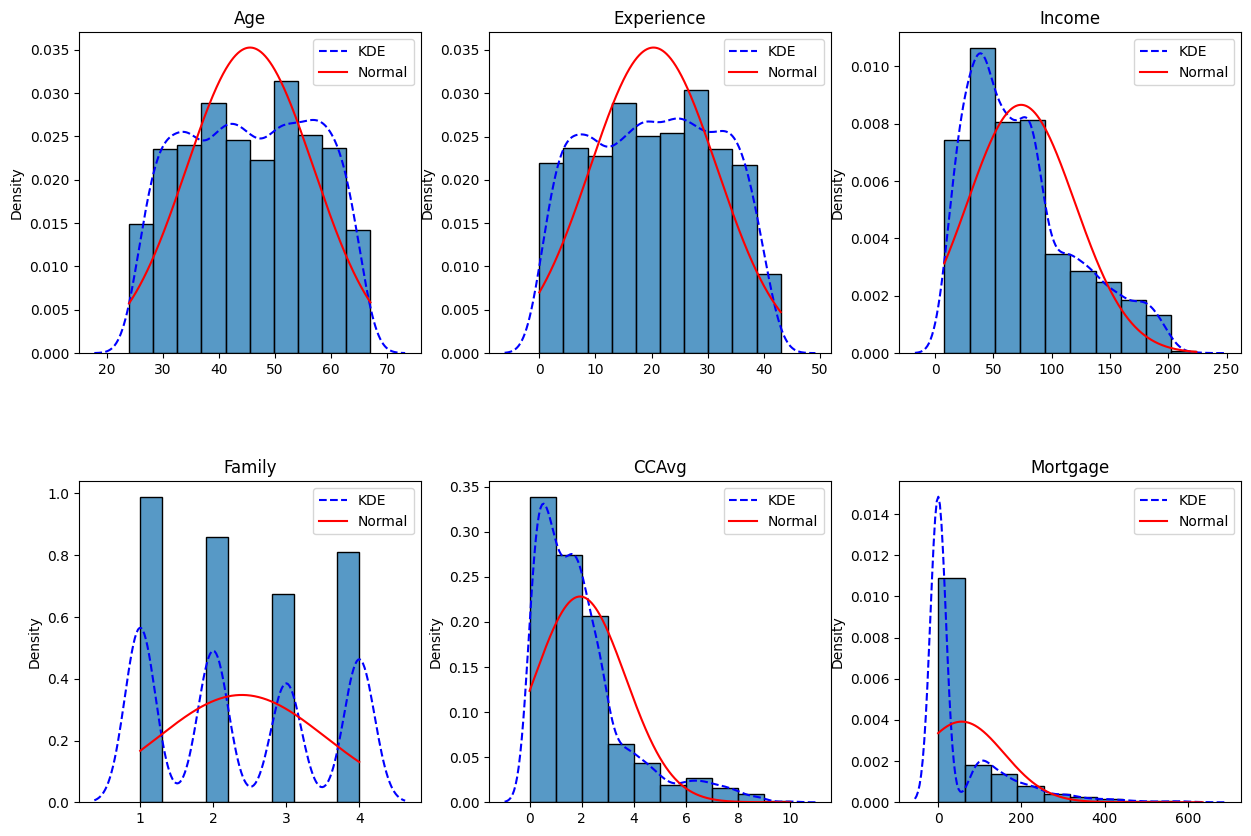

In [18]:
fig, axes = plt.subplots(2,3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4)
axes = axes.ravel()

for col, ax in zip(loan_df[num_cols], axes):
  sns.histplot(x=loan_df[col], bins=10, ax=ax,stat='density')
  sns.kdeplot(x=loan_df[col], ax=ax, linestyle='dashed', color='blue', label='KDE')

  x = np.linspace(loan_df[col].min(), loan_df[col].max(), 1000)
  normal_ref = norm.pdf(x, loan_df[col].mean(), loan_df[col].std())
  ax.plot(x, normal_ref, color='red', label = 'Normal')

  ax.set(title=f'{col}', xlabel=None)
  ax.legend()

These box plots allow us to observe the relationship between the mean and the median. In the case of `Age`, as previously mentioned, the distribution is approximately symmetrical, meaning both values ​​are very similar; however, for `Income` and `Mortage`, we observe a lack of symmetry, specifically a positive skewn as the mean lies to the right of the median, as shown in the graphs.

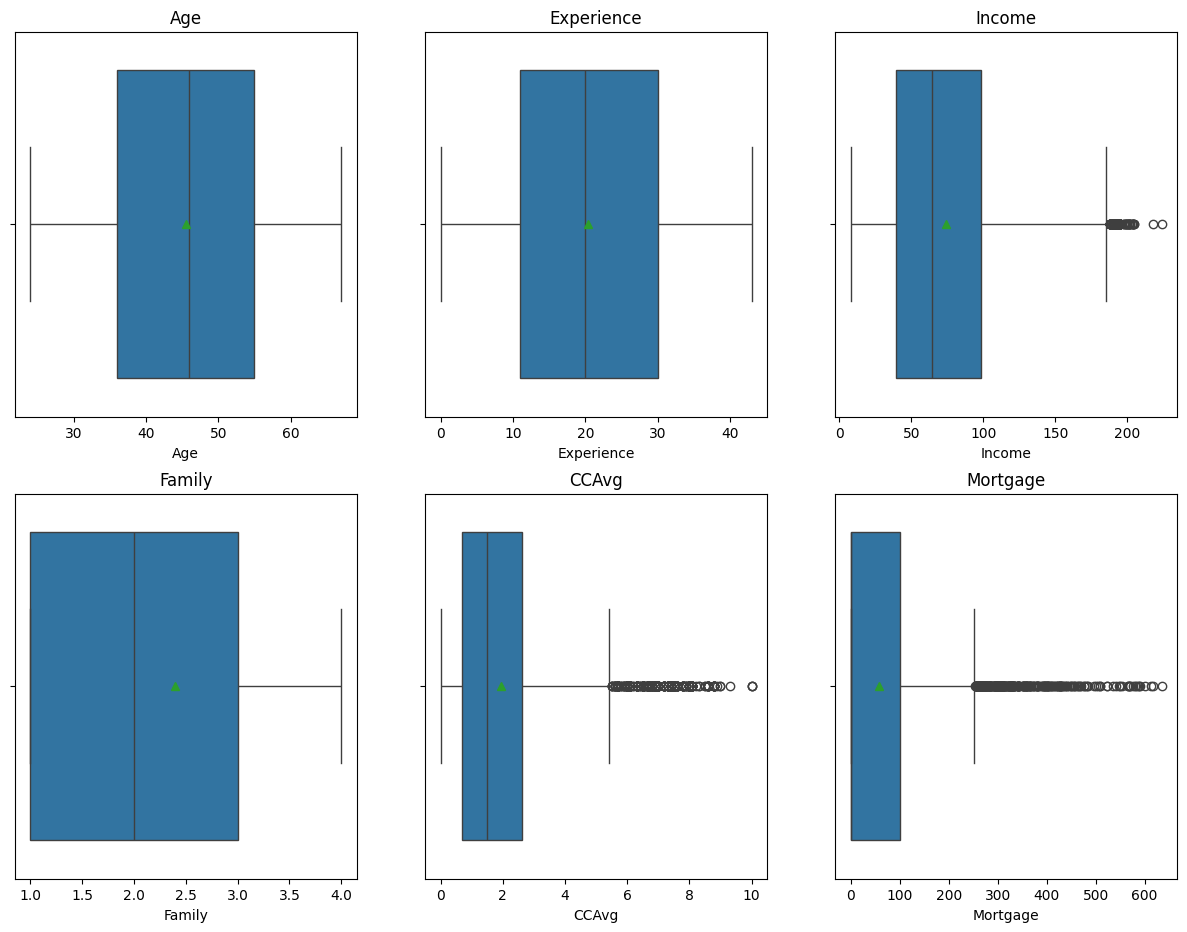

In [19]:
fig, axes = plt.subplots(2,3, figsize=(15, 11))
axes = axes.ravel()

for col, ax in zip(loan_df[num_cols], axes):
  sns.boxplot(x=loan_df[col], ax=ax, showmeans=True)
  ax.set(title=f'{col}')

8. Obtain descriptive statistics for the categorical variables.
* Generate a bar chart for each variable. For high-cardinality variables, include only the 10 most relevant values.


---



In [20]:
cat_stats = loan_df[cat_cols].describe().T
cat_stats

,count,unique,top,freq
ZIP Code,4943,468,94720,163
Education,4942,3,1,2079
Personal Loan,4943,2,No,4464
Securities Account,4943,2,No,4427
CD Account,4943,2,No,4641
Online,4943,2,Yes,2953
CreditCard,4943,2,No,3489


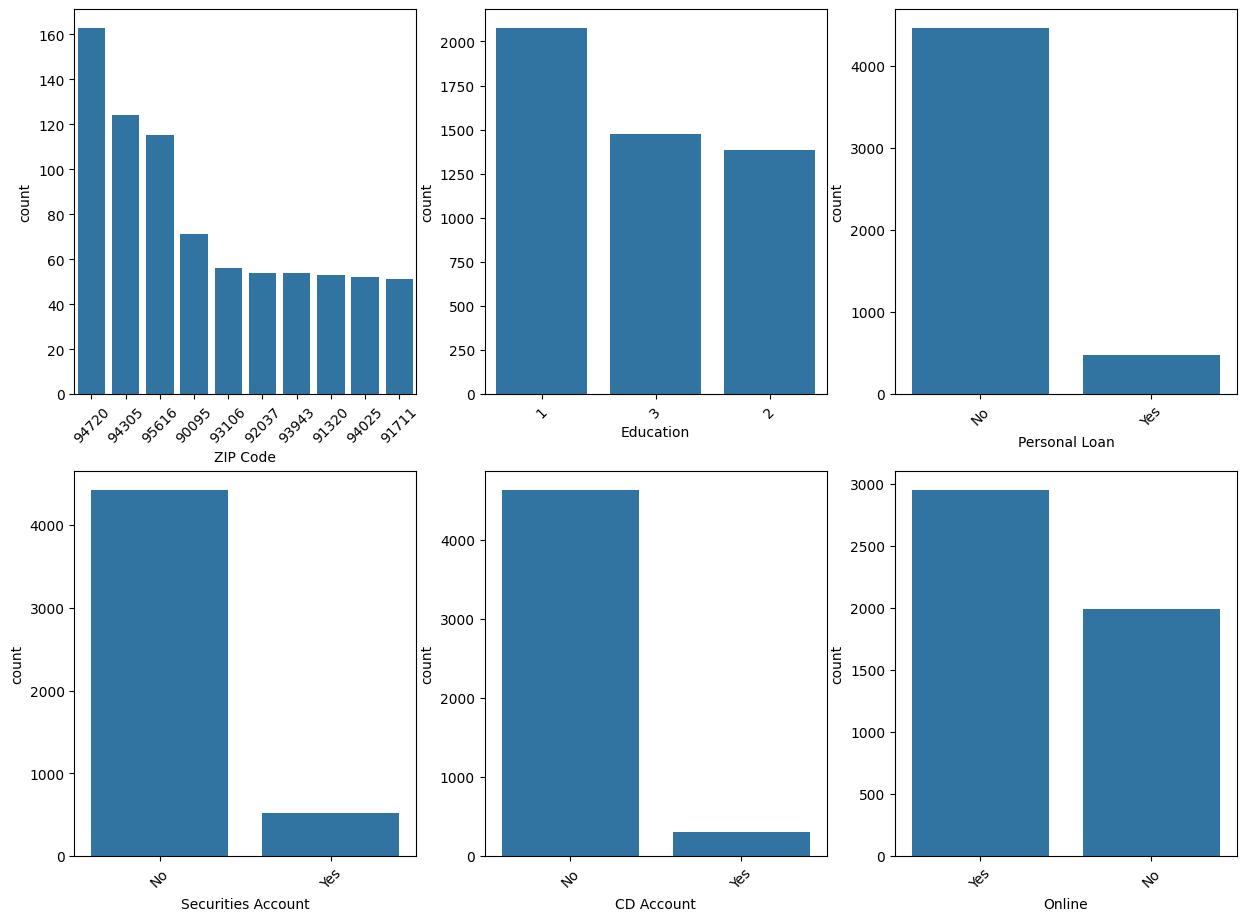

In [21]:
fig, axes = plt.subplots(2,3, figsize=(15, 11))
axes = axes.ravel()
for col, ax in zip(loan_df[cat_cols], axes):
  sns.countplot(x=loan_df[col], ax=ax, order=loan_df[col].value_counts().index[:10])
  ax.tick_params(axis='x', rotation=45)

# Exploratory data analysis (bivariate)

9. Obtain the scatter matrix for all numerical variables.
* Observe the relationships between the variables, select a representative pair, and describe any evident patterns or trends.
* To quantify the strength and direction of the observed relationships, generate a heatmap showing Pearson correlation values. Does the numerical value obtained for the selected pair align with expectations?


---



With this scatter plot matrix, we can identify relationships between variables; for example, we observe that `Age` and `Experience` exhibit a very strong positive relationship, as indicated by the clear linear pattern in the graph.

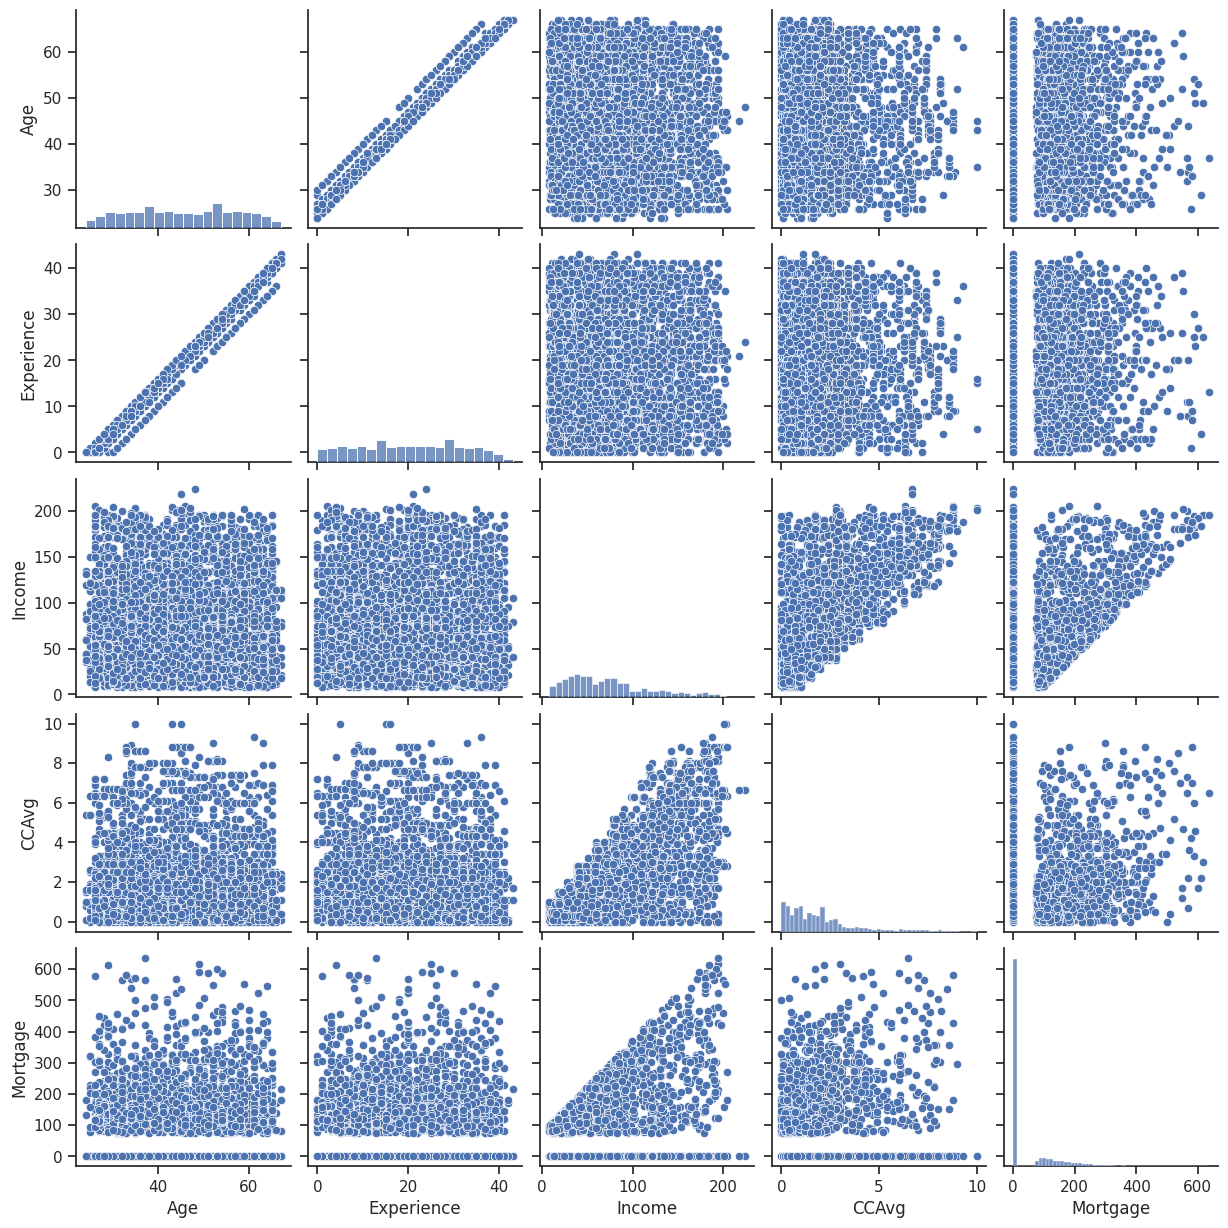

In [22]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(loan_df, vars=['Age','Experience','Income','CCAvg','Mortgage'])
plt.show()

With this heatmap, we can obtain the Pearson correlation values ​​for these relationships, which reflect the strength and direction of the linear relationship between two variables. Furthermore, this heatmap allows us to confirm that the relationship between `Age` and `Experience` is close to 1, thereby validating that both variables are highly correlated.

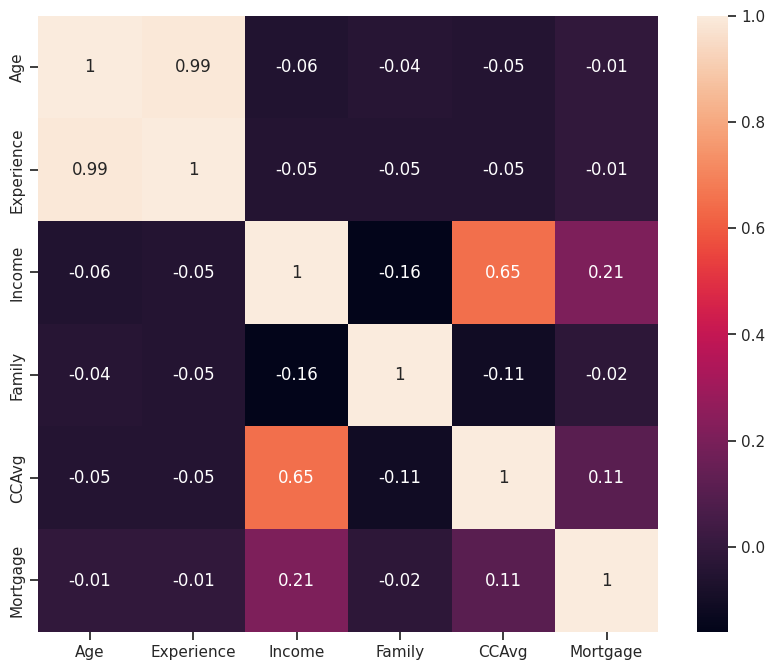

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(round(loan_df[num_cols].corr(),2), annot=True)
plt.show()

10. Conduct an analysis of all dataset variables in relation to the target variable `Personal Loan`.
* Numerical variables: Generate box plots to compare the distribution of each variable based on the values ​​of `Personal Loan`.
* Categorical variables (excluding `ZIP Code`): Generate stacked bar charts showing the relative distribution of `Personal Loan` within each category of the variable.
* For each group of variables (numerical and categorical), comment on at least one relevant finding or pattern observed in the generated charts.


---



Based on these box plots, broken down by `Personal Loan` acceptance, we can identify which variables show the strongest association with the customer's decision to accept the loan.

Customers who accepted the loan tend to have higher `Income` and higher `CCAvg` than those who did not.

`Family` size also differs between the groups; those who accepted the loan generally have larger families 3 to 4 members, although this distinction is not as pronounced as it is for `Income` or `CCAvg`.

In contrast, `Age` and `Experience` show a clear overlap between those who accepted the loan and those who did not, suggesting that, on their own, these variables have little discriminatory power regarding the outcome.

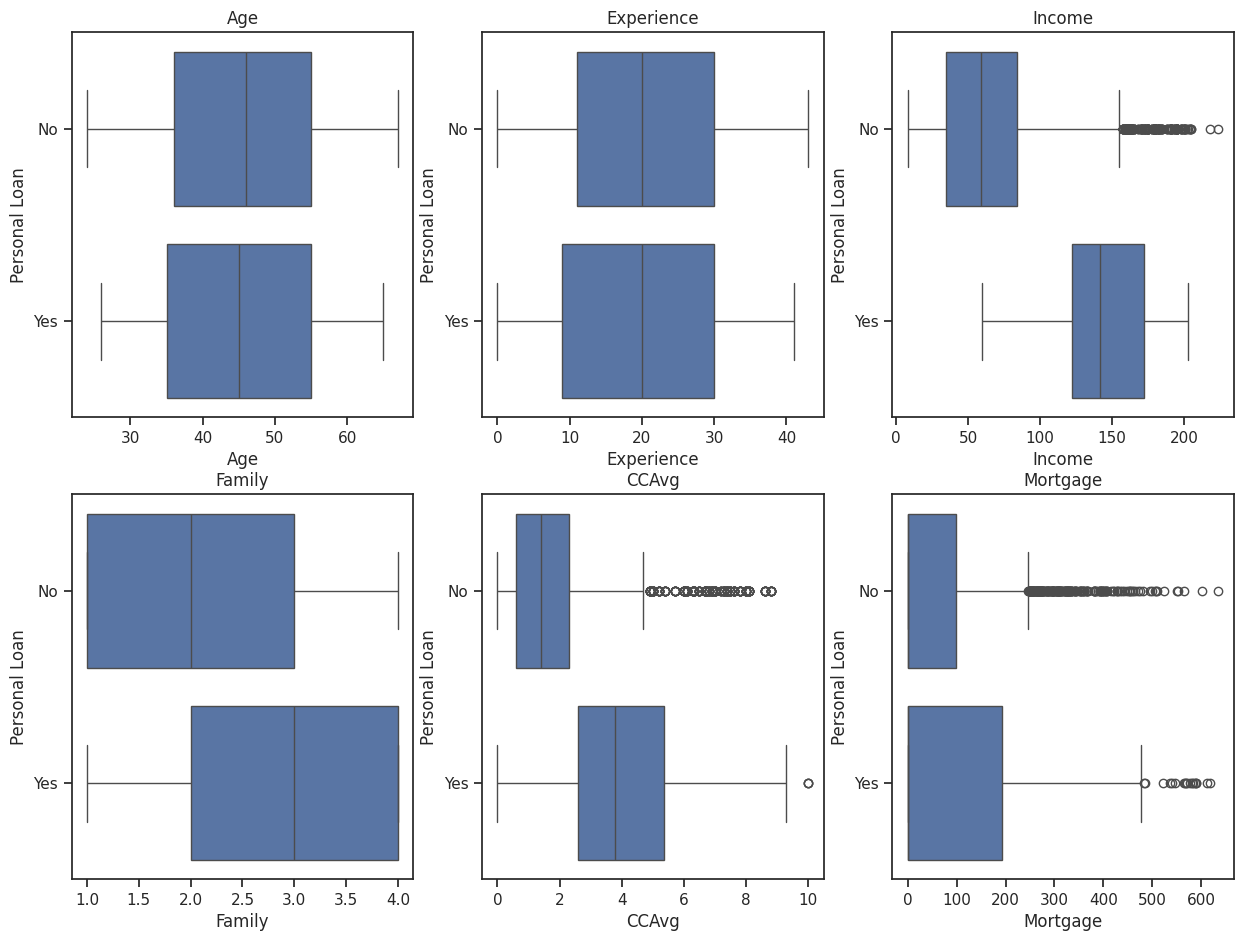

In [24]:
fig, axes = plt.subplots(2,3, figsize=(15, 11))
axes = axes.ravel()
for col, ax in zip(loan_df[num_cols], axes):
  sns.boxplot(x=loan_df[col], ax=ax, y=loan_df['Personal Loan'])
  ax.set(title=f'{col}')

These bar charts show a marked class imbalance: the majority of customers did not accept the loan.

`Education` level shows a clear positive association with loan acceptance.

The `CD Account` shows the strongest association among the six categorical variables: customers who hold a `CD Account` tend to accept the loan, whereas those who do not, do not.

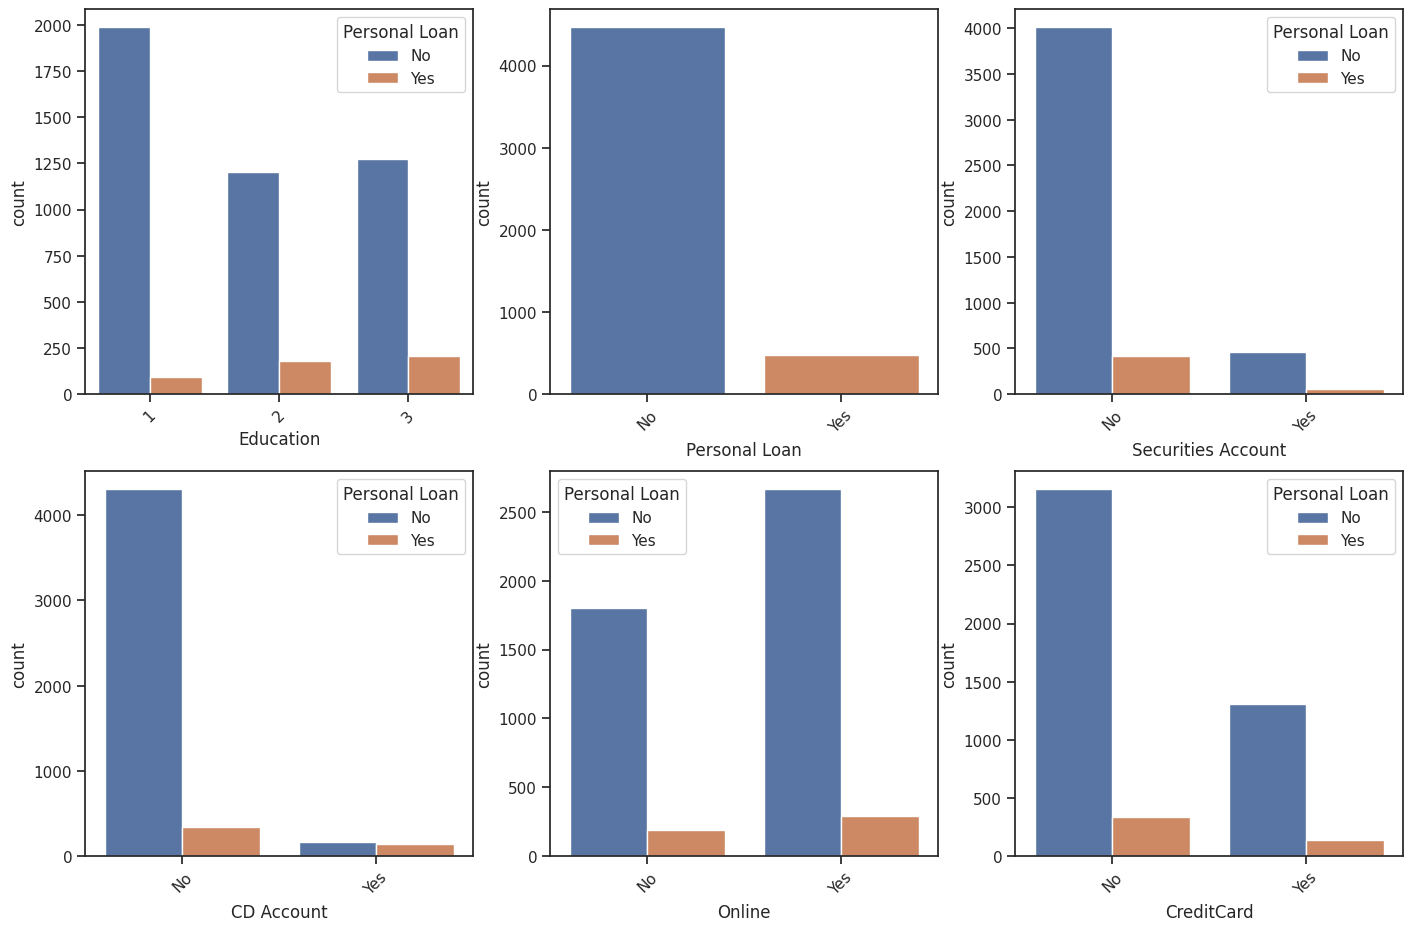

In [25]:
fig, axes = plt.subplots(2,3, figsize=(17, 11))
axes = axes.ravel()
cat_cols.pop(cat_cols.index('ZIP Code'))
for col, ax in zip(loan_df[cat_cols],axes):
  sns.countplot(x = loan_df[col],ax=ax, hue=loan_df['Personal Loan'])
  ax.tick_params(axis='x', rotation=45)

---
**AI Usage Statement**
*   Anthropic. (2026) *Claude (claude-sonnet-4-6)* [Large language model],
used for code generation and debugging. https://claude.ai
---